In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('pca_dataset.csv')
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,cluster_label
0,-1.8661,3.3246,1.3495,0.9464,-3.2059,-3.4582,0
1,-2.8025,2.8165,0.8427,0.9522,-4.1075,3.8147,1
2,2.0840,-2.1134,-2.8457,-2.6786,-1.8669,1.1242,2
3,-1.0104,3.0769,2.2672,0.1788,-2.6474,-3.7319,0
4,-4.1994,3.0278,1.1782,1.7503,-3.8931,3.6087,1


In [3]:
X = df.drop("cluster_label", axis=1)

y = df["cluster_label"]

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [5]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [6]:
print(pca.explained_variance_ratio_)

[0.7236342  0.226193   0.02417677 0.0110654  0.00925715 0.00567347]


In [7]:
print(np.cumsum(pca.explained_variance_ratio_))

[0.7236342  0.94982721 0.97400398 0.98506939 0.99432653 1.        ]


In [8]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [9]:
print(X_pca.shape)

(300, 3)


In [10]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2" ,"PC3"]
)

pca_df["cluster_label"] = y

print(pca_df.head())

        PC1       PC2       PC3  cluster_label
0  1.119939 -1.389377 -0.536407              0
1  1.780852  1.254233 -0.385325              1
2 -2.662087  0.790264 -0.240877              2
3  0.685099 -1.812161 -0.275854              0
4  2.240499  1.137324  0.039248              1


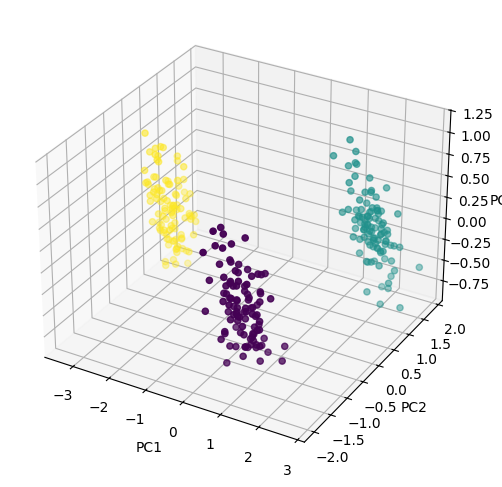

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')  # this line makes it 3D

ax.scatter(pca_df["PC1"], pca_df["PC2"], pca_df["PC3"],
           c=pca_df["cluster_label"])

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")   # extra z axis
plt.show()

In [12]:
import nbformat
print(nbformat.__version__)

5.10.4


In [13]:
import plotly.express as px

fig = px.scatter_3d(pca_df,
    x='PC1', y='PC2', z='PC3',
    color='cluster_label')
fig.show()  # opens in browser, fully rotatable